# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RaihanBasha7/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The action queue translates the validated model output into a practical **human-review priority list**.

The queue does not tell a content owner that a page must be refreshed. Instead, it answers a narrower question:

> **Which pages should a reviewer inspect first, based on the model's observed ranking signal and the page-level characteristics available at review time?**

Each recommendation receives a small set of reason codes so that the ranking is interpretable.

Reason codes describe observed signals:

- **AGE** — content age is relatively high in the modeling population.
- **STALE** — time since the last update is relatively high.
- **VISIBILITY** — average search position is relatively weak among pages with usable position data.
- **CTR** — click-through rate is relatively low.
- **PERFORMANCE** — recent impressions are relatively low.
- **MULTI** — multiple signals point in the same direction.

The ranking is a prioritization mechanism, not a causal claim. A high-ranked page is a candidate for review, not proof that refreshing it will improve performance.

The final action should be selected by a human after checking search intent, content quality, business value, technical context, and recent changes.

In [22]:
# Connect Colab to the repository safely.
# This avoids repeatedly cloning the repository inside itself.

from pathlib import Path
import os
import subprocess

REPO_URL = "https://github.com/RaihanBasha7/flyrank-ml-internship.git"
REPO_DIR = Path("/content/flyrank-ml-internship")

if not REPO_DIR.exists():
    subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_DIR)],
        check=True
    )
else:
    print("Repository already exists.")

os.chdir(REPO_DIR)

print("Repository root:")
print(Path.cwd())

assert (Path.cwd() / "data" / "raw" / "content_refresh_anonymized.csv").exists()
assert (Path.cwd() / "work" / "notebooks").exists()

print("\nRepository structure verified.")

Repository already exists.
Repository root:
/content/flyrank-ml-internship

Repository structure verified.


In [23]:
# Section 1 — Generate the validated out-of-sample action queue.
#
# This reproduces the ML-08 modeling setup:
# - target: is_declining_label
# - grouped 80/20 split by client_id
# - random_state=42
# - Random Forest with 200 trees
# - IDs and label-derived leakage columns excluded
#
# The queue is ranked using the model's out-of-sample probability
# for the declining-content class.

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------
# 1. Load the same FlyRank starter dataset used in ML-08
# ---------------------------------------------------------

ROOT = Path.cwd()

DATA_PATH = ROOT / "data" / "raw" / "content_refresh_anonymized.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

# ---------------------------------------------------------
# 2. Recreate the ML-08 target
# ---------------------------------------------------------

target = "is_declining_label"

df[target] = (
    df["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)

print("\nTarget distribution:")
print(df[target].value_counts())

# ---------------------------------------------------------
# 3. Remove identifiers and leakage columns
# ---------------------------------------------------------

drop_columns = [
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct",
    target,
]

X = df.drop(columns=drop_columns)
y = df[target]

groups = df["client_id"]

print("\nPredictor columns:", X.shape[1])

# ---------------------------------------------------------
# 4. Recreate the honest grouped split
# ---------------------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

test_rows = df.iloc[test_idx].copy()

print("\nGrouped split:")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

overlap = train_clients.intersection(test_clients)

print("Training clients:", len(train_clients))
print("Testing clients:", len(test_clients))
print("Client overlap:", len(overlap))

assert len(overlap) == 0, (
    "Grouped split failed: train/test clients overlap."
)

# ---------------------------------------------------------
# 5. Recreate the ML-08 preprocessing + Random Forest
# ---------------------------------------------------------

categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns

numeric_cols = X_train.select_dtypes(
    exclude=["object"]
).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols,
        ),
        (
            "num",
            "passthrough",
            numeric_cols,
        ),
    ]
)

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
            ),
        ),
    ]
)

# ---------------------------------------------------------
# 6. Train only on the grouped training clients
# ---------------------------------------------------------

model.fit(X_train, y_train)

# ---------------------------------------------------------
# 7. Generate OUT-OF-SAMPLE probabilities
# ---------------------------------------------------------

test_probability = model.predict_proba(X_test)[:, 1]

test_prediction = model.predict(X_test)

# ---------------------------------------------------------
# 8. Build the action queue
# ---------------------------------------------------------

action_queue = test_rows[
    [
        "content_age_days",
        "days_since_last_update",
        "impressions_90d",
        "avg_position",
        "ctr",
        "word_count",
    ]
].copy()

action_queue["decline_probability"] = test_probability
action_queue["predicted_declining"] = test_prediction
action_queue["actual_declining_label"] = y_test.to_numpy()

# ---------------------------------------------------------
# 9. Reason-code signals
#
# These explain why a high-ranked page may deserve review.
# They do NOT explain the Random Forest probability itself.
# ---------------------------------------------------------

action_queue["position_available"] = (
    action_queue["avg_position"].notna()
    & (action_queue["avg_position"] > 0)
)

age_q75 = action_queue["content_age_days"].quantile(0.75)
stale_q75 = action_queue["days_since_last_update"].quantile(0.75)
impressions_q25 = action_queue["impressions_90d"].quantile(0.25)
ctr_q25 = action_queue["ctr"].quantile(0.25)

position_values = action_queue.loc[
    action_queue["position_available"],
    "avg_position",
]

position_q75 = position_values.quantile(0.75)

action_queue["AGE"] = (
    action_queue["content_age_days"] >= age_q75
)

action_queue["STALE"] = (
    action_queue["days_since_last_update"] >= stale_q75
)

action_queue["PERFORMANCE"] = (
    action_queue["impressions_90d"] <= impressions_q25
)

action_queue["CTR"] = (
    action_queue["ctr"] <= ctr_q25
)

action_queue["VISIBILITY"] = (
    action_queue["position_available"]
    & (
        action_queue["avg_position"]
        >= position_q75
    )
)

reason_columns = [
    "AGE",
    "STALE",
    "VISIBILITY",
    "CTR",
    "PERFORMANCE",
]

action_queue["signal_count"] = (
    action_queue[reason_columns]
    .sum(axis=1)
)

def build_reason_code(row):
    reasons = [
        reason
        for reason in reason_columns
        if bool(row[reason])
    ]

    if len(reasons) >= 2:
        return "MULTI|" + "|".join(reasons)

    if len(reasons) == 1:
        return reasons[0]

    return "MIXED"

action_queue["reason_code"] = action_queue.apply(
    build_reason_code,
    axis=1,
)

# ---------------------------------------------------------
# 10. Convert probability into review priority
#
# Thresholds are ranking bands, not causal/business cutoffs.
# ---------------------------------------------------------

action_queue["action_priority"] = pd.qcut(
    action_queue["decline_probability"],
    q=[0, 0.50, 0.80, 1.0],
    labels=[
        "LOW",
        "MEDIUM",
        "HIGH",
    ],
    duplicates="drop",
)

# ---------------------------------------------------------
# 11. Rank highest probability first
# ---------------------------------------------------------

action_queue = action_queue.sort_values(
    [
        "decline_probability",
        "signal_count",
    ],
    ascending=[
        False,
        False,
    ],
).reset_index(drop=True)

action_queue.insert(
    0,
    "review_rank",
    np.arange(
        1,
        len(action_queue) + 1,
    ),
)

# ---------------------------------------------------------
# 12. Final paper-facing queue
# ---------------------------------------------------------

queue_columns = [
    "review_rank",
    "action_priority",
    "decline_probability",
    "reason_code",
    "signal_count",
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "ctr",
    "word_count",
]

ranked_queue = action_queue[
    queue_columns
].copy()

print("\nFinal ranked queue:", ranked_queue.shape)

print("\nPriority distribution:")
print(
    ranked_queue["action_priority"]
    .value_counts()
    .sort_index()
)

print("\nTop 20 review candidates:")
display(
    ranked_queue.head(20)
)

Dataset shape: (30000, 44)

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Predictor columns: 40

Grouped split:
Training rows: 23837
Testing rows: 6163
Training clients: 25
Testing clients: 7
Client overlap: 0

Final ranked queue: (6163, 11)

Priority distribution:
action_priority
LOW       3092
MEDIUM    1870
HIGH      1201
Name: count, dtype: int64

Top 20 review candidates:


,review_rank,action_priority,decline_probability,reason_code,signal_count,content_age_days,days_since_last_update,impressions_90d,avg_position,ctr,word_count
0,1,HIGH,0.970,MIXED,0,95,20,1425,6.2,0.28,3067.0
1,2,HIGH,0.965,MULTI|STALE|CTR,2,223,102,428,12.3,0.00,1634.0
2,3,HIGH,0.965,CTR,1,117,20,580,1.3,0.00,2754.0
3,4,HIGH,0.965,STALE,1,275,104,1828,5.6,0.22,1504.0
4,5,HIGH,0.965,CTR,1,141,20,817,5.7,0.00,2531.0
5,6,HIGH,0.965,CTR,1,117,20,402,6.4,0.00,2924.0
6,7,HIGH,0.965,MIXED,0,95,20,1305,5.7,0.38,2455.0
7,8,HIGH,0.960,CTR,1,90,8,197,10.4,0.00,2771.0
8,9,HIGH,0.960,CTR,1,117,20,535,3.1,0.00,2539.0
9,10,HIGH,0.960,MIXED,0,145,20,795,10.1,0.13,2975.0


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

This playbook is intended for content and SEO teams that need to prioritize a large content inventory for **human review**.

The validated Random Forest provides an out-of-sample probability that an item belongs to the declining-content class. That probability is used to rank review candidates.

The playbook can help a reviewer:

- prioritize which content items to inspect first;
- identify items with stronger model-based decline signals;
- understand which observable page characteristics support the review priority;
- group review candidates into practical content archetypes;
- create a repeatable refresh-review backlog.

### What the model does not establish

The model does **not** establish that:

- a page is objectively low quality;
- content age causes decline;
- updating a page will improve traffic, CTR, or ranking;
- the model predicts Google's algorithm;
- the same ranking performance will hold for every future client or content population;
- a high model probability means a refresh is always the correct action.

The model was evaluated using a client-grouped holdout, so the test set represents unseen clients within this dataset. This supports a cautious out-of-sample ranking interpretation, but it does not guarantee future performance.

### Decision boundary

The model is therefore used as **decision-support**:

**model ranking → human review → action decision**

It is not:

**model ranking → automatic content change**

The final action remains the responsibility of the content owner or reviewer.

In [24]:
# Section 2 — Intended-use evidence and scope checks.

print("Dataset size:", len(df))
print("Out-of-sample queue size:", len(ranked_queue))

print("\nValidation boundary:")
print(" - Ranking is generated from the grouped test set.")
print(" - Test clients were not present in the training clients.")
print(" - Model probability is used for prioritization.")
print(" - Human review remains mandatory.")

print("\nModel score summary:")
print(
    ranked_queue["decline_probability"]
    .describe()
    .round(4)
)

if "actual_declining_label" in action_queue.columns:
    print("\nObserved test-set label rate:")
    print(
        f"{action_queue['actual_declining_label'].mean():.2%}"
    )

# Confirm the queue really contains out-of-sample predictions.
assert len(test_idx) == len(ranked_queue)
assert len(overlap) == 0

print("\nScope checks passed.")

Dataset size: 30000
Out-of-sample queue size: 6163

Validation boundary:
 - Ranking is generated from the grouped test set.
 - Test clients were not present in the training clients.
 - Model probability is used for prioritization.
 - Human review remains mandatory.

Model score summary:
count    6163.0000
mean        0.5197
std         0.2218
min         0.0000
25%         0.3650
50%         0.5300
75%         0.7000
max         0.9700
Name: decline_probability, dtype: float64

Observed test-set label rate:
51.10%

Scope checks passed.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

The ranked queue is a **review queue**, not an automatic publishing queue.

A reviewer should inspect the highest-ranked items and confirm the context before taking action.

### Human review checklist

Before approving a refresh, the reviewer should check:

1. **Search intent** — does the content still satisfy the intended user need?
2. **Accuracy** — are important claims and facts still correct?
3. **Freshness** — has the topic, product, policy, or market context changed?
4. **Search context** — has the competitive search landscape changed?
5. **Performance context** — does the observed decline signal appear meaningful rather than temporary noise?
6. **Technical context** — could indexing, canonicalization, internal linking, or measurement explain the signal?
7. **Business value** — is the expected value worth the human effort?
8. **Recent edits** — was the content already updated recently?

### Archetype → action mapping

The model score determines **priority**. The reason codes help determine **what the reviewer should investigate**.

| Archetype | Typical evidence | Recommended human action |
|---|---|---|
| **Refresh candidate** | High model probability + AGE/STALE | Review factual freshness and update outdated sections |
| **Visibility candidate** | High model probability + VISIBILITY | Inspect search intent, structure, internal links, and SERP competition |
| **CTR candidate** | High model probability + CTR | Review title/meta presentation and intent alignment |
| **Performance candidate** | High model probability + PERFORMANCE | Investigate recent demand/performance changes before refreshing |
| **Multi-signal candidate** | High model probability + MULTI | Highest-priority comprehensive review |
| **Monitor** | Lower model probability or MIXED evidence | Monitor rather than immediately allocating refresh effort |

These archetypes are operational labels for human review. They are not causal explanations of why a page declined.

### No-go list

The system should **never automatically**:

- publish rewritten content;
- delete content;
- change factual claims;
- change prices or legally important information;
- modify medical or safety-critical information;
- make irreversible SEO changes;
- classify content as permanently "low quality";
- claim that a refresh caused an improvement;
- make client-specific decisions without owner review.

The safe automation boundary is **ranking + explanation + review prioritization**.

In [25]:
# Section 3 — Create practical review archetypes.

def assign_archetype(row):
    reasons = str(row["reason_code"])
    probability = row["decline_probability"]

    # Highest-priority multi-signal candidates.
    if (
        probability >= ranked_queue["decline_probability"].quantile(0.80)
        and reasons.startswith("MULTI")
    ):
        return "Multi-signal candidate"

    if (
        probability >= ranked_queue["decline_probability"].quantile(0.80)
        and "AGE" in reasons
    ):
        return "Refresh candidate"

    if (
        probability >= ranked_queue["decline_probability"].quantile(0.80)
        and "STALE" in reasons
    ):
        return "Refresh candidate"

    if (
        probability >= ranked_queue["decline_probability"].quantile(0.80)
        and "VISIBILITY" in reasons
    ):
        return "Visibility candidate"

    if (
        probability >= ranked_queue["decline_probability"].quantile(0.80)
        and "CTR" in reasons
    ):
        return "CTR candidate"

    if (
        probability >= ranked_queue["decline_probability"].quantile(0.80)
        and "PERFORMANCE" in reasons
    ):
        return "Performance candidate"

    return "Monitor"


ranked_queue["archetype"] = ranked_queue.apply(
    assign_archetype,
    axis=1,
)

archetype_actions = {
    "Refresh candidate":
        "Human review for factual/content freshness and update opportunities.",
    "Visibility candidate":
        "Human review of search intent, structure, internal links, and competition.",
    "CTR candidate":
        "Human review of title/meta presentation and search-intent alignment.",
    "Performance candidate":
        "Investigate recent performance and demand context before refreshing.",
    "Multi-signal candidate":
        "Highest-priority comprehensive human review.",
    "Monitor":
        "Monitor rather than immediately allocating refresh effort.",
}

no_go_cases = [
    "publish rewritten content",
    "delete content",
    "change factual claims",
    "change prices or legally important information",
    "modify medical or safety-critical information",
    "make irreversible SEO changes",
    "classify content as permanently low quality",
    "claim that a refresh caused an improvement",
    "make client-specific decisions without owner review",
]

print("\nNo-go automation cases:")
for item in no_go_cases:
    print(" -", item)

ranked_queue["recommended_action"] = (
    ranked_queue["archetype"]
    .map(archetype_actions)
)

# Qualitative review-effort guidance.
# No monetary value is invented because the dataset does not provide
# reliable page-level business value.

def assign_review_effort(row):
    if row["archetype"] == "Multi-signal candidate":
        return "HIGH"

    if row["archetype"] in [
        "Refresh candidate",
        "Visibility candidate",
        "CTR candidate",
    ]:
        return "MEDIUM"

    return "LOW"


ranked_queue["review_effort"] = ranked_queue.apply(
    assign_review_effort,
    axis=1,
)

print("\nReview-effort distribution:")
display(
    ranked_queue["review_effort"]
    .value_counts()
    .rename_axis("review_effort")
    .reset_index(name="count")
)

print("Archetype distribution:")
display(
    ranked_queue["archetype"]
    .value_counts()
    .rename_axis("archetype")
    .reset_index(name="count")
)

print("\nArchetype → action mapping:")
for archetype, action in archetype_actions.items():
    print(f"\n{archetype}")
    print(f"  → {action}")

print("\nTop 20 review candidates:")
display(
    ranked_queue[
        [
            "review_rank",
            "action_priority",
            "decline_probability",
            "reason_code",
            "archetype",
            "recommended_action",
        ]
    ].head(20)
)


No-go automation cases:
 - publish rewritten content
 - delete content
 - change factual claims
 - change prices or legally important information
 - modify medical or safety-critical information
 - make irreversible SEO changes
 - classify content as permanently low quality
 - claim that a refresh caused an improvement
 - make client-specific decisions without owner review

Review-effort distribution:


,review_effort,count
0,LOW,5231
1,HIGH,522
2,MEDIUM,410


Archetype distribution:


,archetype,count
0,Monitor,5230
1,Multi-signal candidate,522
2,CTR candidate,275
3,Refresh candidate,90
4,Visibility candidate,45
5,Performance candidate,1



Archetype → action mapping:

Refresh candidate
  → Human review for factual/content freshness and update opportunities.

Visibility candidate
  → Human review of search intent, structure, internal links, and competition.

CTR candidate
  → Human review of title/meta presentation and search-intent alignment.

Performance candidate
  → Investigate recent performance and demand context before refreshing.

Multi-signal candidate
  → Highest-priority comprehensive human review.

Monitor
  → Monitor rather than immediately allocating refresh effort.

Top 20 review candidates:


,review_rank,action_priority,decline_probability,reason_code,archetype,recommended_action
0,1,HIGH,0.970,MIXED,Monitor,Monitor rather than immediately allocating ref...
1,2,HIGH,0.965,MULTI|STALE|CTR,Multi-signal candidate,Highest-priority comprehensive human review.
2,3,HIGH,0.965,CTR,CTR candidate,Human review of title/meta presentation and se...
3,4,HIGH,0.965,STALE,Refresh candidate,Human review for factual/content freshness and...
4,5,HIGH,0.965,CTR,CTR candidate,Human review of title/meta presentation and se...
5,6,HIGH,0.965,CTR,CTR candidate,Human review of title/meta presentation and se...
6,7,HIGH,0.965,MIXED,Monitor,Monitor rather than immediately allocating ref...
7,8,HIGH,0.960,CTR,CTR candidate,Human review of title/meta presentation and se...
8,9,HIGH,0.960,CTR,CTR candidate,Human review of title/meta presentation and se...
9,10,HIGH,0.960,MIXED,Monitor,Monitor rather than immediately allocating ref...


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Decay / refresh insight

Content age and time since the last update are useful operational signals to inspect because they describe content freshness.

However, this dataset is observational. Therefore, a relationship between age, update recency, and the model's decline ranking should be described as an **observed association or directional pattern**, not as evidence that aging or refreshing causes performance changes.

The analysis below compares model-ranked groups and summarizes how content age and update recency vary across the queue.

This can support a practical review rule:

> Older or less recently updated content that also receives a high model-based decline probability deserves earlier human inspection.

It does **not** support:

> Updating old content will improve performance.

### Monitoring

The playbook can become stale when:

- the observed declining-label rate changes materially;
- important feature distributions shift;
- model-score distributions change substantially;
- grouped holdout performance degrades on newly labelled data;
- the content population changes;
- the target definition changes.

These are investigation triggers, not automatic retraining commands.

### Cost/value boundary

The dataset does not provide reliable page-level revenue or conversion value, so this notebook does not invent monetary ROI estimates.

Instead, value is handled as a human review consideration:

- HIGH effort: comprehensive review is justified when multiple signals align.
- MEDIUM effort: targeted investigation is appropriate.
- LOW effort: monitor before allocating substantial refresh effort.

A future production system could combine the model score with verified business-value signals such as traffic value, conversions, or strategic importance.

### Retraining rule

Retraining should happen only after investigating why performance changed.

The strongest evidence for retraining is degraded performance on a new, properly held-out dataset using the same grouped validation design.

In [26]:
# Section 4 — Decay / refresh analysis.

import numpy as np
import pandas as pd

# Rejoin the original test-set fields needed for the operational analysis.
analysis = ranked_queue.copy()

# Model-score bands.
analysis["score_band"] = pd.qcut(
    analysis["decline_probability"],
    q=[0, 0.50, 0.80, 1.00],
    labels=["Lower 50%", "Middle 30%", "Top 20%"],
    duplicates="drop",
)

decay_summary = (
    analysis
    .groupby("score_band", observed=False)
    .agg(
        n=("decline_probability", "size"),
        median_decline_probability=(
            "decline_probability",
            "median",
        ),
        median_content_age_days=(
            "content_age_days",
            "median",
        ),
        median_days_since_last_update=(
            "days_since_last_update",
            "median",
        ),
    )
    .reset_index()
)

print("Decay / refresh summary by model-score band:")
display(decay_summary)

# Compare top 20% against the rest.
top20 = analysis["score_band"] == "Top 20%"
rest = analysis["score_band"] != "Top 20%"

top20_age = analysis.loc[
    top20, "content_age_days"
].median()

rest_age = analysis.loc[
    rest, "content_age_days"
].median()

top20_stale = analysis.loc[
    top20, "days_since_last_update"
].median()

rest_stale = analysis.loc[
    rest, "days_since_last_update"
].median()

print("\nObserved directional comparison:")
print(
    f"Top-20% median content age: {top20_age:.1f} days"
)
print(
    f"Other 80% median content age: {rest_age:.1f} days"
)
print(
    f"Top-20% median days since update: {top20_stale:.1f} days"
)
print(
    f"Other 80% median days since update: {rest_stale:.1f} days"
)

print(
    "\nInterpretation:"
)
print(
    "These are observed differences in this test population. "
    "They do not establish that age or refreshing causes decline or improvement."
)

# ---------------------------------------------------------
# Cost/value proxy
# ---------------------------------------------------------
#
# We intentionally do not invent revenue or monetary values.
# Instead, use review feasibility as a qualitative planning dimension.

# Review effort was assigned in Section 3.
# Reuse that operational label for monitoring summaries.

print("\nReview-effort distribution:")
display(
    analysis["review_effort"]
    .value_counts()
    .rename_axis("review_effort")
    .reset_index(name="count")
)

# ---------------------------------------------------------
# Monitoring baseline
# ---------------------------------------------------------

monitoring = {
    "declining_label_rate": float(
        df[target].mean()
    ),
    "queue_rows": int(len(ranked_queue)),
    "high_priority_share": float(
        (
            ranked_queue["action_priority"] == "HIGH"
        ).mean()
    ),
    "model_score_median": float(
        ranked_queue["decline_probability"].median()
    ),
    "model_score_q25": float(
        ranked_queue["decline_probability"].quantile(0.25)
    ),
    "model_score_q75": float(
        ranked_queue["decline_probability"].quantile(0.75)
    ),
}

monitor_features = [
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "ctr",
    "word_count",
]

for feature in monitor_features:
    values = pd.to_numeric(
        df[feature],
        errors="coerce",
    )

    monitoring[f"{feature}_median"] = float(
        values.median()
    )

    monitoring[f"{feature}_median"] = float(
        values.median()
    )

print("\nMonitoring baseline:")
for key, value in monitoring.items():
    if "share" in key or "rate" in key:
        print(f"{key}: {value:.2%}")
    else:
        print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")

print("\nRetrain / investigation triggers:")
for trigger in [
    "Material label-distribution shift",
    "Material feature-distribution shift",
    "Substantial model-score distribution shift",
    "Material degradation on new grouped holdout data",
    "Major content-population change",
    "Change in target definition",
]:
    print(" -", trigger)

Decay / refresh summary by model-score band:


,score_band,n,median_decline_probability,median_content_age_days,median_days_since_last_update
0,Lower 50%,3092,0.365,390.0,20.0
1,Middle 30%,1870,0.635,271.0,20.0
2,Top 20%,1201,0.800,181.0,20.0



Observed directional comparison:
Top-20% median content age: 181.0 days
Other 80% median content age: 326.0 days
Top-20% median days since update: 20.0 days
Other 80% median days since update: 20.0 days

Interpretation:
These are observed differences in this test population. They do not establish that age or refreshing causes decline or improvement.

Review-effort distribution:


,review_effort,count
0,LOW,5231
1,HIGH,522
2,MEDIUM,410



Monitoring baseline:
declining_label_rate: 54.21%
queue_rows: 6163
high_priority_share: 19.49%
model_score_median: 0.5300
model_score_q25: 0.3650
model_score_q75: 0.7000
content_age_days_median: 236.0000
days_since_last_update_median: 20.0000
impressions_90d_median: 731.0000
avg_position_median: 10.8000
ctr_median: 0.0700
word_count_median: 2877.0000

Retrain / investigation triggers:
 - Material label-distribution shift
 - Material feature-distribution shift
 - Substantial model-score distribution shift
 - Material degradation on new grouped holdout data
 - Major content-population change
 - Change in target definition


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

This notebook produces the artifacts that the research paper can reuse.

### Ranked action queue

`work/outputs/ranked_action_queue.csv`

This is the regenerated review queue. It contains the model-based review rank, probability, reason codes, archetype, and recommended human action.

The queue is intentionally regenerated rather than treated as a committed dataset.

### Paper metrics

`work/outputs/action_playbook_metrics.json`

This contains aggregate metrics and monitoring values used to support the recommendations section.

### Decay / refresh summary

`work/outputs/decay_refresh_summary.csv`

This records the observed age and update-recency differences across model-score bands.

### Figure

`work/figures/model_score_by_priority.png`

This figure can be reused in the research paper to show how the model probability is distributed across the operational priority groups.

All outputs are aggregate or operational artifacts. No client names, URLs, private queries, or client identifiers are intentionally exported.

The paper should describe the queue as a **decision-support artifact**, not as evidence that refreshing the ranked pages will cause improved performance.


Paper metrics saved to: /content/flyrank-ml-internship/work/outputs/action_playbook_metrics.json


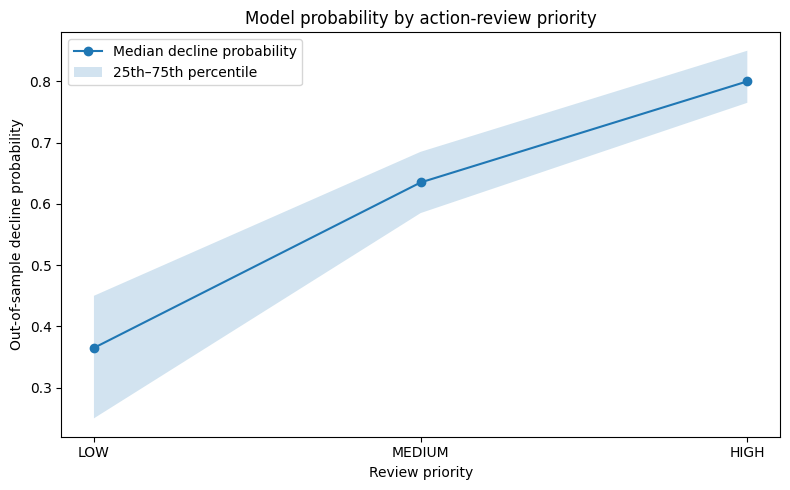


Created artifacts:
 - /content/flyrank-ml-internship/work/outputs/ranked_action_queue.csv
 - /content/flyrank-ml-internship/work/outputs/action_playbook_metrics.json
 - /content/flyrank-ml-internship/work/outputs/decay_refresh_summary.csv
 - /content/flyrank-ml-internship/work/figures/model_score_by_priority.png

Queue rows exported: 6163
Decay rows exported: 3

All paper exports verified.


In [28]:
# Section 5 — Export paper-ready artifacts.

import json
from pathlib import Path
import matplotlib.pyplot as plt

OUTPUT_DIR = ROOT / "work" / "outputs"
FIGURES_DIR = ROOT / "work" / "figures"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

QUEUE_PATH = (
    OUTPUT_DIR / "ranked_action_queue.csv"
)

METRICS_PATH = (
    OUTPUT_DIR / "action_playbook_metrics.json"
)

DECAY_PATH = (
    OUTPUT_DIR / "decay_refresh_summary.csv"
)

FIGURE_PATH = (
    FIGURES_DIR / "model_score_by_priority.png"
)

# ---------------------------------------------------------
# 1. Ranked queue
# ---------------------------------------------------------

export_columns = [
    "review_rank",
    "action_priority",
    "decline_probability",
    "reason_code",
    "signal_count",
    "archetype",
    "recommended_action",
    "review_effort",
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "ctr",
    "word_count",
]

ranked_queue[
    [c for c in export_columns if c in ranked_queue.columns]
].to_csv(
    QUEUE_PATH,
    index=False,
)

# ---------------------------------------------------------
# 2. Decay / refresh summary
# ---------------------------------------------------------

decay_summary.to_csv(
    DECAY_PATH,
    index=False,
)

# ---------------------------------------------------------
# 3. Paper metrics
# ---------------------------------------------------------

human_review_required = True

archetype_counts = (
    ranked_queue["archetype"]
    .value_counts()
    .to_dict()
)

reason_counts = (
    ranked_queue["reason_code"]
    .value_counts()
    .head(10)
    .to_dict()
)

paper_metrics = {
    "source_rows": int(len(df)),
    "test_rows": int(len(ranked_queue)),
    "test_clients": int(len(test_clients)),
    "client_overlap": int(len(overlap)),

    "high_priority_count": int(
        (ranked_queue["action_priority"] == "HIGH").sum()
    ),

    "medium_priority_count": int(
        (ranked_queue["action_priority"] == "MEDIUM").sum()
    ),

    "low_priority_count": int(
        (ranked_queue["action_priority"] == "LOW").sum()
    ),

    "high_priority_share": float(
        (ranked_queue["action_priority"] == "HIGH").mean()
    ),

    "observed_declining_label_rate": float(
        df[target].mean()
    ),

    "model_probability_median": float(
        ranked_queue["decline_probability"].median()
    ),

    "model_probability_q25": float(
        ranked_queue["decline_probability"].quantile(0.25)
    ),

    "model_probability_q75": float(
        ranked_queue["decline_probability"].quantile(0.75)
    ),

    "archetype_counts": archetype_counts,
    "reason_code_counts": reason_counts,

    "human_review_required": human_review_required,

    "causal_claim_supported": False,

    "automation_boundary": [
        "ranking",
        "reason_codes",
        "review_prioritization",
    ],

    "monitoring_baseline": monitoring,
}

# ---------------------------------------------------------
# 4. Save paper metrics JSON
# ---------------------------------------------------------

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        paper_metrics,
        f,
        indent=2,
    )

print(
    f"\nPaper metrics saved to: {METRICS_PATH}"
)

# ---------------------------------------------------------
# 5. Reusable figure
# ---------------------------------------------------------

priority_order = [
    "LOW",
    "MEDIUM",
    "HIGH",
]

plot_data = (
    ranked_queue
    .groupby(
        "action_priority",
        observed=False,
    )["decline_probability"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
    .reindex(priority_order)
)

plt.figure(figsize=(8, 5))

plt.plot(
    plot_data.index,
    plot_data["median"],
    marker="o",
    label="Median decline probability",
)

plt.fill_between(
    range(len(plot_data)),
    plot_data["q25"],
    plot_data["q75"],
    alpha=0.2,
    label="25th–75th percentile",
)

plt.xticks(
    range(len(plot_data)),
    plot_data.index,
)

plt.ylabel("Out-of-sample decline probability")
plt.xlabel("Review priority")
plt.title(
    "Model probability by action-review priority"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_PATH,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------
# 6. Verify exports
# ---------------------------------------------------------

print("\nCreated artifacts:")
for path in [
    QUEUE_PATH,
    METRICS_PATH,
    DECAY_PATH,
    FIGURE_PATH,
]:
    print(" -", path)
    assert path.exists()

print("\nQueue rows exported:", len(
    pd.read_csv(QUEUE_PATH)
))

print(
    "Decay rows exported:",
    len(pd.read_csv(DECAY_PATH))
)

print("\nAll paper exports verified.")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.